<a href="https://colab.research.google.com/github/jesuscastellanosesp/analisis-everpeak/blob/main/everpike.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Subtítulo

In [ ]:
# Nombre de dónde estudio
plataforma_educativa = "TripleTen"
print(plataforma_educativa)

TripleTen


In [ ]:
# curso que estoy estudiando
mi_curso = ''

# Sprint en el que estoy
mi_sprint = ''

In [ ]:
# imprimir información curso
print('Estoy estudiando el curso de', mi_curso, 'en', plataforma_educativa)
#print('Estoy en el sprint')

Estoy estudiando el curso de  en TripleTen


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/datasets/everpeak_retail.csv')


In [ ]:
df_clean = df.copy()


In [ ]:
df.head()

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66.0
1,2,2024-10-10,1736,Grocery,66,0,660,debit_card,Los Angeles,CA,24.0
2,3,2024-08-27,2543,Sports,267,0,5073,credit_card,Chicago,IL,23.0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70.0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75.0


In [ ]:
payment_missing = df['payment_method'].isna().sum()
city_missing = df['city'].isna().sum()
state_missing = df['state'].isna().sum()

print("payment_method missing:", payment_missing)
print("city missing:", city_missing)
print("state missing:", state_missing)

payment_method missing: 0
city missing: 100
state missing: 100


In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

invalid_year_2026_count = (df["order_date"].dt.year == 2026).sum()
missing_order_date_count =  df["order_date"].isna().sum()

print("order_date año 2026:", invalid_year_2026_count)
print("order_date missing:", missing_order_date_count)

order_date año 2026: 15
order_date missing: 8


In [ ]:
customer_id_unicos = df["customer_id"].nunique()
payment_unicos = df["payment_method"].nunique()
city_unicos = df["city"].nunique()
state_unicos = df["state"].nunique()

print("customer_id nunique:", customer_id_unicos)
print("payment_method nunique:", payment_unicos)
print("city nunique:", city_unicos)
print("state nunique:", state_unicos)

customer_id nunique: 1829
payment_method nunique: 4
city nunique: 10
state nunique: 9


In [ ]:
#revisar que tipo de causas hay para datos que faltan
# MCAR — Faltante completamente al azar (Missing Completely at Random)
# MAR — faltan siguiendo un patrón externo (Missing at Random)
# MNAR — faltan porque el propio valor es especial
#filtrar edad de compra  y relacionar con ciudad
df['customer_age'].isna().groupby(df['city']).mean().sort_values(ascending=False)

city
New York         0.048290
Boston           0.037975
San Francisco    0.032051
Los Angeles      0.031311
Seattle          0.031189
Miami            0.030181
Phoenix          0.024440
Houston          0.023346
Chicago          0.020747
Denver           0.019523
Name: customer_age, dtype: float64

In [ ]:
#filtrar edad y relacionar por producto
df['customer_age'].isna().groupby(df['product_category']).mean()

product_category
?              0.000000
Beauty         0.027739
Electronics    0.031250
Fashion        0.025676
Grocery        0.027778
Home           0.029455
Sports         0.049716
Toys           0.019471
Name: customer_age, dtype: float64

In [ ]:
#dividios las edades vacias y las registradas en dos grupos, observamos muestra
df['edad_vacia'] = df['customer_age'].isna().astype(int)
df.head()

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,edad_vacia
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66.0,0
1,2,2024-10-10,1736,Grocery,66,0,660,debit_card,Los Angeles,CA,24.0,0
2,3,2024-08-27,2543,Sports,267,0,5073,credit_card,Chicago,IL,23.0,0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70.0,0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75.0,0


In [ ]:
df.groupby("edad_vacia")["order_value"].describe()
# comparar valor de copra entre ambos grupos

,count,mean,std,min,25%,50%,75%,max
edad_vacia,,,,,,,,
0,4858.0,10108.75916,12406.435518,12.0,3158.25,10411.5,13163.0,303824.0
1,150.0,8866.96000,12102.064531,37.0,1993.75,5023.0,11405.5,78964.0


In [ ]:
#rellenar faltantes con mediana,
#calcular mediana
median_age = df['customer_age'].median()
print(median_age)

49.0


In [ ]:
#usar ediana para rellenar
df['customer_age'] = df['customer_age'].fillna(median_age)

#imputar por valor determinado, 30 por ejemplo
# df['customer_age'] = df['customer_age'].fillna(30)

#imputar por variable
# edad_fija = 35
# df['customer_age'] = df['customer_age'].fillna(edad_fija)

In [ ]:
#verificar cuantos vacios quedaron
df['customer_age'].isna().sum()

0

In [ ]:
# eliminar ERRORES (menores a cero)

# primero vemos cuantos valores faltan en pedido
df['quantity'].le(0).sum()

2971

In [ ]:
# Marcar como NaN los valores inválidos de quantity
import numpy as np
df.loc[df['quantity'] <= 0, 'quantity'] = np.nan

In [ ]:
# El valor total del pedido dividido entre el precio unitario debería darnos la cantidad.
# Comprobamos si la cantidad calculada (order_value / price) coincide con la columna quantity
df['calculated_quantity'] = df['order_value'] / df['price']

# Verificamos las primeras filas donde la cantidad es cero o inválida
df[['order_value', 'price', 'quantity', 'calculated_quantity']].head()

,order_value,price,quantity,calculated_quantity
0,13385,269,50.0,49.758364
1,660,66,NaN,10.000000
2,5073,267,NaN,19.000000
3,14290,114,125.0,125.350877
4,11754,729,16.0,16.123457


In [ ]:
# Imputar los valores faltantes con el cálculo de order_value / price (round muestra 1.0)
df['quantity'] = (df['order_value'] / df['price']).round()
#rellenar los faltantes .fillna()
df['quantity'] = df['quantity'].fillna(df['order_value'] / df['price'])
#esta segunda lina es redundante, hace algo que ya se hizo con la primera
# si queremos usar fillna() la primer linea deberia establecerse como variable

In [ ]:
#verificar
df['quantity'].le(0).sum()

0

no veo la diferencia entre usar o no .fillna() por que al final los valores serian los mismos, incluso sihay otros errores se corregirian

Tu razonamiento es correcto:
En este caso específico, NO hay diferencia práctica entre usar o no .fillna() porque:

### Escenario 1: Sin .fillna()
python
df['quantity'] = (df['order_value'] / df['price']).round()

- Recalcula TODOS los valores
- Resultado: quantity = order_value ÷ price

### Escenario 2: Con .fillna()
python
df['quantity'] = df['quantity'].fillna((df['order_value'] / df['price']).round())

- Solo rellena los valores faltantes
- Pero como quantity debería ser order_value ÷ price, el resultado final es el mismo

¿Por qué tu enfoque es mejor?
Tienes razón al decir que "incluso si hay otros errores se corregirían":
✅Corrige valores faltantes (NaN)
✅ Corrige errores de cálculo previos
✅ Garantiza consistencia en toda la columna
✅ Más simple de escribir y entender

En la práctica:
Cuando tienes una relación matemática clara como quantity = order_value ÷ price, es mejor recalcular todo para asegurar consistencia total.

en que casos si se recomineda usar .fillna()?

Casos donde .fillna() es la mejor opción:
1. Cuando los datos originales son confiables
# Ejemplo: Edades de clientes
df['age'].fillna(df['age'].median())
¿Por qué? Si tienes 1000 edades correctas y solo 50 faltantes, no quieres perder esos 1000 valores buenos.
2. Cuando NO hay una fórmula matemática clara
# Ejemplo: Nombres de ciudades faltantes
df['city'].fillna('Unknown')
¿Por qué? No puedes "calcular" el nombre de una ciudad. Solo puedes rellenar lo que falta.
3. Cuando quieres preservar datos históricos
# Ejemplo: Precios históricos de productos
df['historical_price'].fillna(method='forward')
¿Por qué? Los precios cambian con el tiempo. Un precio de enero no debería ser recalculado con datos de diciembre.
4. Cuando los datos correctos son la mayoría
# Ejemplo: Solo 5% de quantity está mal
df['quantity'].fillna((df['order_value'] / df['price']).round())
¿Por qué? Si el 95% de los datos son correctos, solo rellenas el 5% faltante.

¿Cuándo recalcular TODO (como en tu caso)?
✅ Cuando hay inconsistencias en los datos existentes
✅ Cuando tienes una relación matemática perfecta
✅ Cuando quieres garantizar coherencia total

USAR .fillna() OSEA RELLENAR SOLO FALTANTES
### 1. Preservas variaciones legítimas del negocio:
- Ofertas especiales (2x1, descuentos por volumen)
- Precios promocionales temporales
- Bundling de productos
- Descuentos por lealtad
### 2. Solo corriges lo que realmente está mal:
- Valores faltantes (NaN) → se calculan
- Valores correctos → se mantienen intactos
### 3. Evitas perder información valiosa:
En el contexto de SilverBasket, una quantity diferente al cálculo matemático podría indicar:
- Estrategias comerciales exitosas
- Patrones de comportamiento del cliente
- Promociones efectivas
Comparación de enfoques:
Enfoque	Ventaja	Desventaja
Recalcular todo	Consistencia matemática	Pierde información de negocio
Tu enfoque (.fillna)	Preserva datos reales + corrige faltantes	Requiere más análisis posterior
## Tu decisión es estratégicamente correcta porque:
✅ Respeta la realidad del negocio
✅ Mantiene señales importantes en los datos
✅ Solo interviene donde es realmente necesario

Estructura de una función en Python
Una función en Python tiene cuatro componentes básicos:

def → le dice a Python “voy a definir una función”.
Nombre de la función → típicamente en minúsculas, con guiones bajos: snake_case.
Parámetros → las entradas entre paréntesis. No es obligatorio, pero comúnmente tenemos una o más entradas.
return → lo que la función devuelve como resultado (no es obligatorio).
Ejemplo básico:

def saludar(nombre):
    return "Hola " + nombre
saludar → nombre de la función.
nombre → parámetro de entrada.
return "Hola " + nombre → salida de la función.

In [ ]:
def elevar_al_cuadrado(x):
    print("El cuadrado de",x, "es",x * x)
elevar_al_cuadrado(4)

El cuadrado de 4 es 16


Método moderno (f-string):

print(f"Hola {nombre}, ¿Cómo estas?")
¿Cómo funciona?
La "f" le dice a Python: "Este texto tiene variables dentro"
Las llaves {} marcan dónde va cada variable
Python automáticamente reemplaza {nombre} con el valor de la variable nombre

In [ ]:
def estandarizar_nombre(nombre):
    return nombre.strip().lower() # o upper para estandarizar a mayusculas
# title para mayuscula primro, despues minusculas
print(estandarizar_nombre("LuIs  "))

luis


def formatear_nombre(nombre, apellido):
    nombre_formateado = nombre.strip().title()
    apellido_formateado = apellido.strip().title()
    return f"El apellido de {nombre_formateado} es {apellido_formateado}"
print(formatear_nombre("  ana  ", "GARCÍA"))
print(formatear_nombre("carlos", "  lópez  "))

In [ ]:
def calcular_descuento(precio, porcentaje_descuento):
    tasa_descuento = porcentaje_descuento / 100  # Convertir porcentaje a decimal
    descuento = precio * tasa_descuento #calcular descuento
    return precio - descuento # restar el descuento al precio
print(calcular_descuento(100, 10))
print(calcular_descuento(250, 20))
print(calcular_descuento(50, 15))

90.0
200.0
42.5


 Definir los rangos específicos por columna
Primero, creamos un diccionario que mapee cada columna con sus valores mínimos y máximos aceptables:

# Definir rangos específicos para cada columna
rangos_columnas = {
    'customer_age': (17, 100),
    'price': (0, 10000),
    'quantity': (1, 100),
    'order_value': (0, 50000)
}
Pregunta: ¿Qué rangos consideras apropiados para las columnas de tu dataset? ¿Hay alguna columna específica en la que estés trabajando?

Paso 2: Crear la función principal con loop interno
Siguiendo el patrón de la lección (función + loop), creamos una función que aplique tu función reemplazar_fuera_de_rango a múltiples columnas:

def limpiar_rangos_columnas(df, rangos_dict):
    for col, (min_val, max_val) in rangos_dict.items():
        if col in df.columns:  # Verificar que la columna existe
            df[col] = reemplazar_fuera_de_rango(df[col], min_val, max_val)
    return df

La función se crea antes de definir las columnas según su tipo porque sigue una metodología de desarrollo paso a paso:

El proceso lógico es:
Primero se desarrolla la lógica individual
Se trabaja con cada tipo de columna por separado (numéricas, categóricas, fechas)
Luego se automatiza con bucles
Se convierte el código repetitivo en bucles for
Después se encapsula en una función
Se agrupa toda la lógica en una función reutilizable
Finalmente se definen las listas de columnas
Se especifica qué columnas van en cada categoría
¿Por qué este orden?
La función imputar_segun_diagnostico() es como crear una "máquina" que puede procesar diferentes tipos de columnas. Una vez que tienes la máquina lista, solo necesitas decirle qué columnas procesar.

Si definieras las columnas primero, tendrías que reescribir código cada vez que cambien los datos. Con la función ya creada, solo cambias las listas:

# Solo cambias esto cuando tengas nuevos datos:
cols_imputar_mediana = ["customer_age", "nueva_columna_numerica"]
cols_imputar_unknown = ["city", "state"]
cols_imputar_fecha = ["order_date"]

def detectar_tipos_columnas(df):
    numericas = df.select_dtypes(include=['int64', 'float64']).columns
    categoricas = df.select_dtypes(include=['object']).columns  # ← Faltaban comillas
    fechas = df.select_dtypes(include=['datetime64']).columns   # ← Faltaban comillas
    return numericas, categoricas, fechas
Mejora adicional:
Para ser más robusto, podrías incluir más tipos numéricos:

def detectar_tipos_columnas(df):
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
    categoricas = df.select_dtypes(include=['object']).columns  
    fechas = df.select_dtypes(include=['datetime64']).columns
    return numericas, categoricas, fechas
Pregunta para probar tu función:
¿Cómo usarías esta función en tu pipeline de limpieza?

En lugar de definir manualmente:

numeric_cols = ["customer_age", "price"]  # Manual
text_cols = ["city", "category"]          # Manual

Lección: Validación y limpieza de datos con pandas (nivel profesional)
🎯 Objetivo

Entender cómo:

definir valores válidos
detectar datos incorrectos
limpiar automáticamente
construir un pipeline reutilizable
🧩 1. Idea clave: el tipo de dato NO define la validación

👉 Un dato numérico puede representar cosas distintas:

Tipo	Ejemplo	Regla válida
edad	25	0–120
precio	199.99	≥ 0
cantidad	3	enteros ≥ 0
descuento	0.2	0–1

💡 Conclusión:

No validas “números”, validas el significado del dato

🔍 2. Cómo definir valores válidos

Ejemplo: edad válida entre 17 y 100

(df["edad"] >= 17) & (df["edad"] <= 100)

👉 Esto genera una máscara booleana:

edad	válido
15	❌
25	✅
120	❌
⚠️ 3. Error común: usar .replace() con condiciones

❌ Incorrecto:

df.replace(<17, pd.NA)

✔️ Correcto:

usar loc
usar where()
🧹 4. Reemplazar valores inválidos correctamente
✔️ Con .loc
mask = (df["edad"] < 17) | (df["edad"] > 100)
df.loc[mask, "edad"] = pd.NA
✔️ Con .where() (más elegante)
df["edad"] = df["edad"].where(
    (df["edad"] >= 17) & (df["edad"] <= 100),
    pd.NA
)
🔁 5. Convertir a numérico antes de validar
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")

👉 Esto convierte errores a NaN

🧠 6. Crear funciones reutilizables
✔️ Función genérica
def reemplazar_fuera_de_rango(col, min_val, max_val):
    col = pd.to_numeric(col, errors="coerce")
    return col.where((col >= min_val) & (col <= max_val), pd.NA)

Uso:

df["edad"] = reemplazar_fuera_de_rango(df["edad"], 17, 100)
🚀 7. Escalar: reglas por columna
reglas = {
    "edad": (17, 100),
    "precio": (0, None),
    "cantidad": (0, None)
}
⚙️ 8. Validación automática
def validar(df, reglas):
    df = df.copy()
    
    for col, (min_val, max_val) in reglas.items():
        mask = True
        
        if min_val is not None:
            mask &= df[col] >= min_val
        if max_val is not None:
            mask &= df[col] <= max_val
        
        df[f"{col}_valido"] = mask
    
    return df
🧹 9. Limpieza automática
def limpiar(df):
    df = df.copy()
    
    # eliminar filas inválidas
    df = df[df["edad_valido"]]
    
    # imputar valores
    df.loc[~df["precio_valido"], "precio"] = df["precio"].median()
    
    # limpiar texto
    df["producto"] = df["producto"].str.strip().str.lower()
    
    return df
🔄 10. Transformación (para análisis)
def transformar(df):
    df = df.copy()
    
    df["total"] = df["precio"] * df["cantidad"]
    
    return df
🧪 11. Pipeline completo
def pipeline_datos(df, reglas):
    df = validar(df, reglas)
    df = limpiar(df)
    df = transformar(df)
    return df

Uso:

df = pipeline_datos(df, reglas)
🔥 12. Flujo mental correcto
datos crudos
   ↓
validación (¿es correcto?)
   ↓
limpieza (arreglar/eliminar)
   ↓
transformación (crear métricas)
   ↓
dataset listo
⚡ 13. Reglas clave (nivel profesional)
✅ Usa .replace() cuando:
valores exactos (ej: -999)
✅ Usa .loc o .where() cuando:
condiciones (rangos, lógica)
🧠 14. Lo más importante de toda la lección

👉 Validar ≠ limpiar
👉 Limpiar ≠ transformar

Son pasos distintos en un pipeline

💡 15. Mentalidad correcta

Antes de escribir código, pregúntate:

¿Qué significa esta columna?
¿Qué valores son imposibles?
¿Qué hago con errores?
🚀 Resultado final

Ahora sabes:

✔️ detectar datos inválidos
✔️ aplicar reglas de negocio
✔️ limpiar automáticamente
✔️ crear funciones reutilizables
✔️ construir pipelines escalables


Modificar la función para crear flags
En lugar de reemplazar valores, vamos a crear columnas nuevas que indiquen si el valor está fuera de rango:

def crear_flags_fuera_de_rango(col, min_val, max_val, col_name):
    col_numeric = pd.to_numeric(col, errors="coerce")
    # Crear flag: True si está fuera de rango, False si está dentro
    flag = ~((col_numeric >= min_val) & (col_numeric <= max_val))
    return flag
Paso 2: Aplicar la función con flags
Ahora modificamos el loop para crear columnas de flags:

# Definir rangos específicos por columna
rangos_columnas = {
    'customer_age': (17, 100),
    'price': (0, 10000),
    'quantity': (1, 100)
}

# Aplicar la función columna por columna creando flags
for col, (min_val, max_val) in rangos_columnas.items():
    if col in df.columns:
        # Crear columna flag con nombre descriptivo
        flag_col_name = f"{col}_fuera_rango"
        df[flag_col_name] = crear_flags_fuera_de_rango(df[col], min_val, max_val, col)

Función combinada que hace ambas cosas
def procesar_fuera_de_rango(col, min_val, max_val, col_name):
    col_numeric = pd.to_numeric(col, errors="coerce")
    
    # 1. Crear flag (True = fuera de rango)
    flag = ~((col_numeric >= min_val) & (col_numeric <= max_val))
    
    # 2. Limpiar valores (reemplazar fuera de rango con NA)
    col_limpio = col_numeric.where((col_numeric >= min_val) & (col_numeric <= max_val), pd.NA)
    
    return flag, col_limpio
Paso 2: Aplicar la función combinada
# Definir rangos específicos por columna
rangos_columnas = {
    'customer_age': (17, 100),
    'price': (0, 10000),
    'quantity': (1, 100)
}

# Aplicar la función columna por columna
for col, (min_val, max_val) in rangos_columnas.items():
    if col in df.columns:
        # Obtener flag y columna limpia
        flag, col_limpia = procesar_fuera_de_rango(df[col], min_val, max_val, col)
        
        # Asignar resultados al DataFrame
        df[f"{col}_fuera_rango"] = flag      # Flag
        df[col] = col_limpia                 # Columna limpia
        

Como paso intermedio antes de crear la función para imputar, usamos un bucle para que este código pueda recibir diferentes columnas.

El bucle recorre la lista de columnas (median_fill) que queremos rellenar con la mediana.
En cada columna, la convertimos a numérica, calculamos su mediana y reemplazamos los valores ausentes con ella.
median_fill_cols =["customer_age"]

for col in median_fill_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    med = df[col].median()
    df[col] = df[col].fillna(med)

Pipeline listo para recibir diferentes DataFrames y listas de columnas a procesar:

# crear función
def clean_data(df,numeric_cols, text_cols, flags_cols,
    median_fill_cols, fill_unknown_cols, date_drop_cols):
    
    # Sentinels: reemplazar marcadores inválidos por NaN
    df = reemplazar_sentinels_global(df, numeric_cols, text_cols)
    
    # Flags: crear banderas antes de imputar
    df = crear_flags(df, flags_cols)
    
    # Imputaciones / drops finales
    df = imputar_segun_diagnostico(df,median_fill_cols,fill_unknown_cols,date_drop_cols)
    return df

Precódigo para aplicar el pipeline a cualquier dataset:

# main_pipeline.py

# definir DataFrame a procesar
df = pd.read_csv(#ruta al DF aquí)

# Listas de columnas - incluir columnas según las necesidades del dataset
## columnas función 1: reemplazar_sentinels
columnas_numericas = []   #lista de columnas aquí
columnas_texto = []       #lista de columnas aquí

## columnas función 2: crear_flags
columnas_flags = []  #lista de columnas aquí

## columnas función 3: imputar_segun_diagnostico
cols_imputar_mediana = []  #lista de columnas aquí
cols_imputar_unknown = []  #lista de columnas aquí
cols_imputar_fecha = []    #lista de columnas aquí

# aplicar función y guardar resultado en df_clean
df_clean = clean_data(df, columnas_numericas, columnas_texto, columnas_flags,
    cols_imputar_mediana, cols_imputar_unknown, cols_imputar_fecha)

# guardar df_clean en un CSV nuevo
df_clean.to_csv("RUTA_AQUI/nombre_archivo.csv", index=False)

Aplicar pipeline al dataset de EverPeak:

# main_pipeline.py

# DataFrame a procesar: Everpeak
df = pd.read_csv("/datasets/everpeak_retail.csv")

# Listas de columnas - incluir columnas según las necesidades del dataset

# columnas a procesar del dataset EverPeak
## columnas función 1: reemplazar_sentinels
columnas_numericas = ["customer_age"]
columnas_texto = ["product_category"]

## columnas función 2: crear_flags
columnas_flags = ["customer_age", "city", "state"]

## columnas función 3: imputar_segun_diagnostico
cols_imputar_mediana = ["customer_age"]
cols_imputar_unknown = ["city", "state"]
cols_imputar_fecha = ["order_date"]

# aplicar función y guardar resultado en df_clean
df_clean = clean_data(df, columnas_numericas, columnas_texto, columnas_flags,
    cols_imputar_mediana, cols_imputar_unknown, cols_imputar_fecha)

# guardar df_clean en un CSV nuevo
df_clean.to_csv("/datasets/everpeak_clean.csv", index=False)

In [ ]:
def reemplazar_sentinels(df, sentinels) :
    df = df.copy()
    df ["customer_age"] = df["customer_age"].replace(sentinels, pd.NA)
    return df

In [ ]:
print("Valores ausentes", df["customer_age"].isna().sum())

# Fijar valores a corregir
valores_erroneos = [-999, 0, 999, -1]

# Aplicar función, guardar resultados y observar cambios
df = reemplazar_sentinels(df, valores_erroneos) # tu código aquí
print("Valores ausentes", df["customer_age"].isna().sum())

Valores ausentes 0
Valores ausentes 25


In [ ]:
def reemplazar_sentinels(df, sentinels, numeric_cols):
        df = df.copy()
        for col in numeric_cols:
            df[col] = df[col].replace(sentinels, pd.NA) # tu código aquí
        return df

In [ ]:
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Fijar valores a corregir y columnas
valores_erroneos = [-999, 999, 0, -1]
numeric_cols = ["customer_age", "price"] # tu código aquí]

# Aplicar función y observar cambios
df = reemplazar_sentinels(df, valores_erroneos, numeric_cols) # tu código aquí
print("\nValores ausentes después:")
print(df[["customer_age", "price"]].isna().sum())

Valores ausentes iniciales:
customer_age    25
price            0
dtype: int64

Valores ausentes después:
customer_age    25
price            2
dtype: int64


In [ ]:
def rellenar_ausentes(df, cols_fill):
    df = df.copy()
    for col in cols_fill: # bucle para recorrer columnas
            df[col] = pd.to_numeric(df[col], errors="coerce") # tu código aquí: convertir a numéri
            df[col].fillna(df[col].mean(), inplace=True) # tu código aquí: rellenar con promedio usando coinplace=True
    return df

In [ ]:
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Definir columnas a rellenar
columnas_rellenar = ["customer_age", "price"] # tu código aquí]

# Aplicar función y observar cambios
df = rellenar_ausentes(df, columnas_rellenar) # tu código aquí
print("\nValores ausentes después:")
print(df[["customer_age", "price"]].isna().sum())

Valores ausentes iniciales:
customer_age    25
price            2
dtype: int64

Valores ausentes después:
customer_age    0
price           0
dtype: int64


In [ ]:
def limpiar_df(df):
    valores_erroneos = [-999, 999, 0, 1.] # tu código aquí: definir valores_erroneos
    columnas_numericas = ["customer_age" , "price"]

    df = reemplazar_sentinels (df, valores_erroneos, columnas_numericas)
    #valores_erroneos, columnas_numericas # tu código aquí: aplicar reemplazar_sentinels
    df = rellenar_ausentes (df, columnas_numericas) # tu código aquí: aplicar rellenar_ausentes

    return df

In [ ]:
print("Valores ausentes iniciales:")
print(df[["customer_age", "price"]].isna().sum())

# Aplicar pipeline completo
df = limpiar_df (df) # tu código aquí
print("\nValores ausentes después del pipeline:")
print(df[["customer_age", "price"]].isna().sum())

Valores ausentes iniciales:
customer_age    0
price           0
dtype: int64

Valores ausentes después del pipeline:
customer_age    0
price           0
dtype: int64


In [ ]:
df['order_value'].describe()

count      5008.000000
mean      10071.564696
std       12398.053370
min          12.000000
25%        3096.250000
50%       10339.500000
75%       13159.250000
max      303824.000000
Name: order_value, dtype: float64

In [ ]:
df['order_value'].mean()
df['order_value'].median()
df['order_value'].std()
df['order_value'].min()
df['order_value'].max()
df['order_value'].count()

5008

 Cuando ejecutas múltiples comandos en una sola celda, solo se muestra el resultado del último comando.

usarprint("nombre",comando)

ejecutarlos por celdas separadas

.describe al ser un solo comando muestra todos los resultados en conjunto


In [ ]:
df.describe() #muestra todos los medidas estadisticas dela tabla

,order_id,customer_id,price,quantity,order_value,customer_age,edad_vacia,calculated_quantity
count,5008.000000,5008.000000,5008.000000,5008.000000,5008.000000,5008.000000,5008.000000,5008.000000
mean,2504.500000,1988.362420,756.090491,32.345447,10071.564696,49.118804,0.029952,32.347585
std,1445.829404,569.889309,1172.518018,93.335506,12398.053370,17.718567,0.170472,93.333554
min,1.000000,1000.000000,12.000000,1.000000,12.000000,18.000000,0.000000,0.857098
25%,1252.750000,1495.000000,218.750000,7.000000,3096.250000,34.000000,0.000000,7.195202
50%,2504.500000,1988.000000,457.000000,14.000000,10339.500000,49.000000,0.000000,14.000000
75%,3756.250000,2475.000000,845.500000,23.000000,13159.250000,64.000000,0.000000,22.698146
max,5008.000000,2999.000000,36708.000000,2083.000000,303824.000000,80.000000,1.000000,2082.545455


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
mean_price = df['price'].mean()
median_price = df['price'].median()

print("Promedio:", mean_price)
print("Mediana:", median_price)

Promedio: 756.0904914103077
Mediana: 457.0


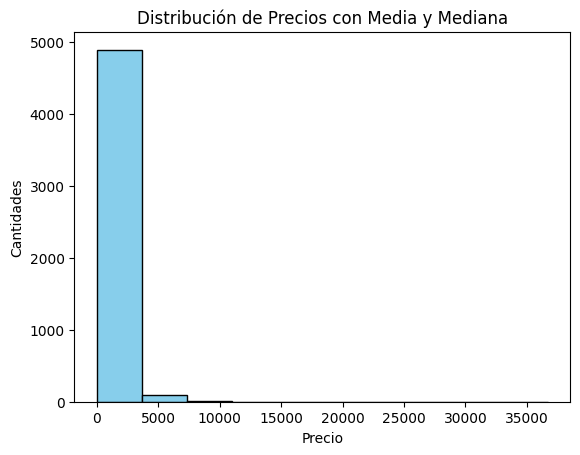

In [ ]:
# Graficar histograma
plt.hist(df['price'], color='skyblue', edgecolor='black')

# Títulos y etiquetas
plt.title('Distribución de Precios con Media y Mediana')
plt.xlabel('Precio')
plt.ylabel('Cantidades')
plt.show()

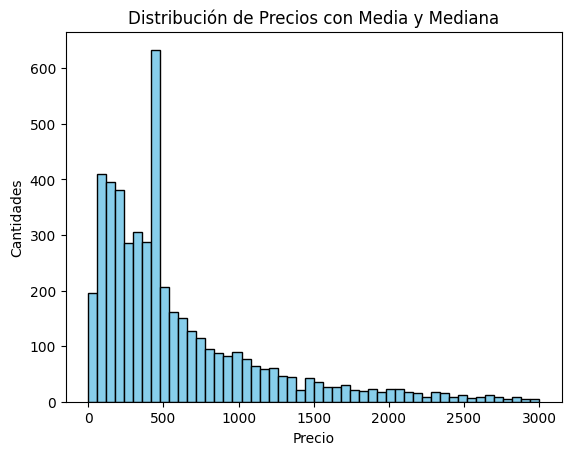

In [ ]:
# Graficar histograma
plt.hist(df['price'], bins=50, range=(0,3000), color='skyblue', edgecolor='black')

# Títulos y etiquetas
plt.title('Distribución de Precios con Media y Mediana')
plt.xlabel('Precio')
plt.ylabel('Cantidades')
plt.show()

## bins=50
¿Qué hace? Divide los datos en 50 grupos (barras)

Analogía: Imagina que tienes una caja de canicas de diferentes tamaños y quieres organizarlas en 50 cajitas según su tamaño. Cada cajita representa una barra del histograma.

Más bins (ej: 100) = Más barras, más detalle
Menos bins (ej: 10) = Menos barras, menos detalle
## color='skyblue'
¿Qué hace? Define el color de relleno de las barras

Resultado: Las barras se ven de color azul cielo

Otros ejemplos: 'red', 'green', 'orange', 'purple'

## edgecolor='black'
¿Qué hace? Define el color del borde de cada barra

Analogía: Es como el contorno de un dibujo. Sin esto, las barras se ven "pegadas" entre sí. Con el borde negro, cada barra se distingue claramente.

Sin borde: Las barras se ven como una masa continua
Con borde: Cada barra tiene su propio contorno

## range=(0,3000)
¿Qué hace? Define el rango de valores que se muestran en el eje X

Significado:
- 0 = Valor mínimo del eje X
- 3000 = Valor máximo del eje X
- Solo se muestran datos entre $0 y $3000

¿Por qué es útil? Si tienes datos desde $0 hasta $50,000, pero la mayoría están entre $0-$3000, este parámetro te permite "hacer zoom" a la parte más interesante.

## Resultado visual:
Un histograma con 50 barras azul cielo, cada una con borde negro, mostrando solo precios entre $0 y $3000.

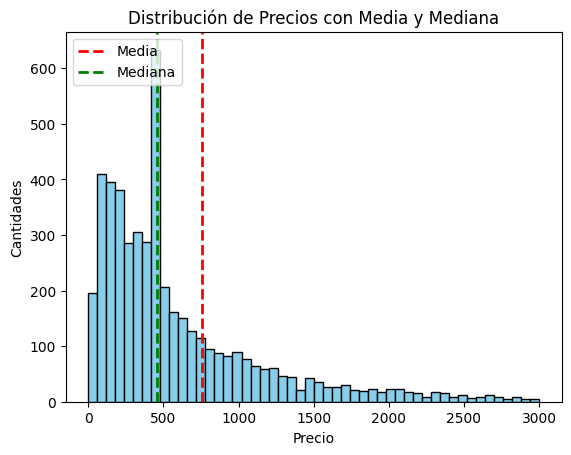

In [ ]:
# Agregamos líneas para poder ver doónde están la media y la mediana.

# Graficar histograma
plt.hist(df['price'], bins=50, range=(0,3000), color='skyblue', edgecolor='black')

# Agregar líneas de media y mediana
plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(median_price, color='green', linestyle='dashed', linewidth=2, label='Mediana')

# Títulos y etiquetas
plt.title('Distribución de Precios con Media y Mediana')
plt.xlabel('Precio')
plt.ylabel('Cantidades')
plt.legend(loc='upper left')
plt.show()

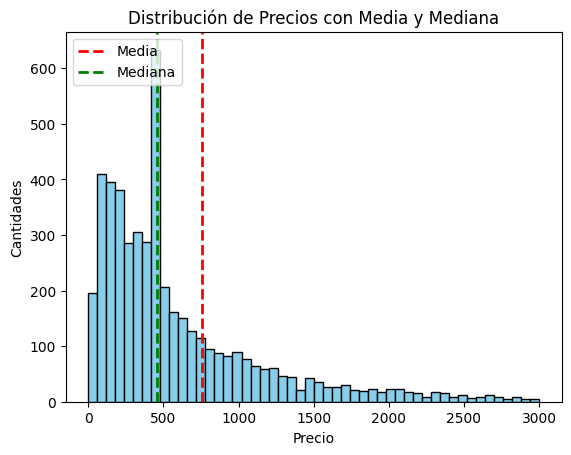

In [ ]:
# Graficar histograma con detalles agregados

plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black', range=(0,3000))

# Agregar líneas de media y mediana
plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(median_price, color='green', linestyle='dashed', linewidth=2, label='Mediana')

# Títulos y etiquetas
plt.title('Distribución de Precios con Media y Mediana')
plt.xlabel('Precio')
plt.ylabel('Cantidades')
plt.legend(loc='upper left')
plt.show()

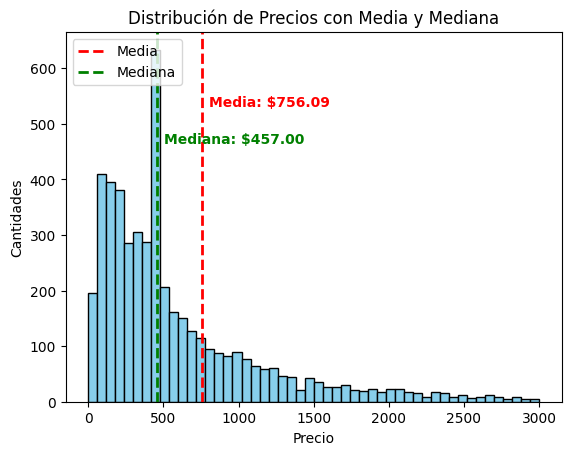

In [ ]:
# Graficar histograma
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black', range=(0,3000))

# Agregar líneas de media y mediana
plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(median_price, color='green', linestyle='dashed', linewidth=2, label='Mediana')
plt.text(mean_price + 50, plt.ylim()[1] * 0.8, f'Media: ${mean_price:.2f}',
         color='red', fontweight='bold')
plt.text(median_price + 50, plt.ylim()[1] * 0.7, f'Mediana: ${median_price:.2f}',
         color='green', fontweight='bold')
# Títulos y etiquetas
plt.title('Distribución de Precios con Media y Mediana')
plt.xlabel('Precio')
plt.ylabel('Cantidades')
plt.legend(loc='upper left')
plt.show()


In [ ]:
# plt.text(mean_price + 50, plt.ylim()[1] * 0.8, f'Media: ${mean_price:.2f}',
         color='red', fontweight='bold')
# plt.text(median_price + 50, plt.ylim()[1] * 0.7, f'Mediana: ${median_price:.2f}',
         color='green', fontweight='bold')

IndentationError: unexpected indent (4028791300.py, line 2)

Desglose detallado:

1. plt.text() = Función que agrega texto al gráfico

2. mean_price + 50 = Posición X del texto
- Toma el valor de la media (ej: 756)
- Le suma 50 píxeles hacia la derecha
- Resultado: El texto aparece 50 unidades a la derecha de la línea roja

3. plt.ylim()[1] * 0.8 = Posición Y del texto
- plt.ylim()[1] = Obtiene la altura máxima del gráfico
- * 0.8 = Multiplica por 0.8 (80% de la altura)
- Resultado: El texto aparece al 80% de la altura del gráfico

4. f'Media: ${mean_price:.2f}' = El texto que se muestra
- Resultado: "Media: $756.00"

5. color='red' = Color rojo (igual que la línea)

6. fontweight='bold' = Texto en negritas

Segunda línea: Texto para la Mediana
plt.text(median_price + 50, plt.ylim()[1] * 0.7, f'Mediana: ${median_price:.2f}',
         color='green', fontweight='bold')
Diferencias clave:

Posición X: median_price + 50 (cerca de la línea verde)
Posición Y: * 0.7 (70% de altura, más abajo que la media)
Color: 'green' (igual que la línea verde)
Texto: "Mediana: $457.00"
¿Por qué diferentes alturas?
Media al 80%: Más arriba
Mediana al 70%: Más abajo
Esto evita que los textos se superpongan y se vean claramente.

Cuando ejecutas plt.show(), matplotlib muestra el gráfico y lo cierra. Después de eso, cualquier comando adicional como plt.text() no tiene efecto porque ya no hay un gráfico activo para modificar.

La solución es simple:
Mueve las líneas plt.text() antes de plt.show():

Organización lógica del código:
En matplotlib, hay una diferencia conceptual entre:

Elementos del gráfico (como líneas, barras, puntos)
Elementos de formato (títulos, etiquetas de ejes, leyenda)
¿Por qué esta separación?
Las etiquetas de texto (plt.text()) son elementos del gráfico, no elementos de formato. Piénsalo así:

plt.title(), plt.xlabel(), plt.ylabel() → Formatean el gráfico
plt.text() → Agrega contenido al gráfico (como las líneas verticales)

Flujo lógico recomendado:
# 1. Crear el histograma
plt.hist(...)

# 2. Agregar elementos al gráfico
plt.axvline(...)  # líneas verticales
plt.text(...)     # etiquetas de valores

# 3. Formatear el gráfico
plt.title(...)    # título
plt.xlabel(...)   # etiqueta eje X
plt.ylabel(...)   # etiqueta eje Y
plt.legend(...)   # leyenda

# 4. Mostrar el resultado
plt.show()

Sin embargo, ambas formas funcionan correctamente. La separación es más una cuestión de organización y legibilidad del código.


In [ ]:
print(df[['order_value', 'customer_age', 'price', 'quantity']].describe())

In [ ]:
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']

for col in columnas_numericas:
    # Media y mediana de cada columna
    print(col)
    print("Promedio", df[col].mean(),"- Mediana:", df[col].median())
    print()

In [ ]:
#  Tarea 1 Crear dataframes para cada categoría
df_fashion = df[df['product_category'] == "Fashion"] # Escribe tu código aquí]
df_sports = df[df['product_category'] == "Sports"] # Escribe tu código aquí]

# --- Resumen de columnas numéricas con describe()
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']

print('Resumen estadístico de la categoría Fashion')
print(df_fashion[columnas_numericas].describe()) # Escribe tu código aquí)

print() #Salto de Línea
print('Resumen estadístico de la categoría Sports')
print(df_sports[columnas_numericas].describe())# Escribe tu código aquí)

In [ ]:
# tarea 2
# Tu misión es comparar la media y la mediana de la columna order_value
# para evaluar si hay valores extremos influyendo en el análisis.
df_grocery = df[df['product_category'] == "Grocery"] # Escribe tu código aquí]

# Calcular media y mediana del gasto
promedio = df_grocery['order_value'].mean()# Escribe tu código aquí
mediana = df_grocery['order_value'].median()# Escribe tu código aquí

# Mostrar resultados
print("Promedio del gasto en Grocery:", promedio)
print("Mediana del gasto en Grocery:", mediana)

# Interpretación según comparación de media y mediana
print("El promedio está afectado por outliers o valores atípicos en Grocery.")
# tu interpretación aquí)

In [ ]:
# tarea3 Tu misión es comparar la  media y la mediana de la columna quantity
# para evaluar si los valores extremos están afectando
# el análisis de la cantidad típica comprada por los clientes.
print("Promedio de quantity: ", df['quantity'].mean()) # tu código aquí)
print("Mediana de quantity: ", df['quantity'].median()) # tu código aquí)
print("El promedio está afectado por los outliers o valores atípicos.")
# tu interpretación aquí)

In [ ]:
#comportamiento de los clientes en las ciudades New York y Los Angeles
#, para comprender su situación actual y detectar posibles anomalías en los datos.
df_ny = df[df['city'] == "New York"]# Escribe tu código aquí]
df_la = df[df['city'] == "Los Angeles"]# Escribe tu código aquí]

# --- Resumen de columnas numéricas con describe()
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']

print('Resumen estadístico de la ciudad New York')
print(df_ny[columnas_numericas].describe()) # Escribe tu código aquí)

print() #Salto de Línea
print('Resumen estadístico de la ciudad Los Angeles')
print(df_la[columnas_numericas].describe())

In [ ]:
df.info() #IDENTIFICAR LAS COLUMNAS CATEGORICAS PARA INGRESAR MANUAL

In [ ]:
columnas_categoricas = ['product_category', 'payment_method', 'city', 'state']

In [ ]:
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

In [ ]:
print(df[columnas_categoricas].describe())

In [ ]:
for col in columnas_categoricas:
    print(col)
    print("Frecuencia absoluta:") #conteo
    print(df[col].value_counts())
    print("\nFrecuencia relativa:") #porcentaje
    print(df[col].value_counts(normalize=True))
    #normalize=True divide el conteo entre el total de valores
    print("")

In [ ]:
df.dtypes

In [ ]:
print(df['order_date'].describe())

In [ ]:
df["product_category"].nunique() #conteo de valores unicos

In [ ]:
print(df["product_category"].value_counts())

In [ ]:
# Columnas categóricas
columnas_categoricas = ['payment_method', 'city']

# Filtra por categoría
df_toys = df[df['product_category'] == "Toys"] # Escribe tu código aquí]

# Resumen categórico Toys
print("Resumen categórico - Toys")
print(df_toys[columnas_categoricas].describe())

In [ ]:
df_sports = df[df['product_category'] == "Sports"] # Escribe tu código aquí]

# Distribución de city
print("Frecuencia absoluta")
print(df_sports['city'].value_counts())
print("\nFrecuencia relativa")
print(df_sports['city'].value_counts(normalize=True))

In [ ]:
# visualisacion de grafica de barras para nuevo dataset
import matplotlib.pyplot as plt
df = pd.read_csv('/datasets/math_class.csv')

# Histograma con Matplotlib
plt.hist(df['score'], bins=15, color='skyblue', edgecolor='black')

plt.xlabel('Notas de los estudiantes')
plt.ylabel('Cantidad de estudianes')
plt.title('Distribución de notas')

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('/datasets/math_class.csv')

# Histograma con Seaborn
sns.histplot(df['score'], bins=15, color='skyblue', kde=True)
# kde=True muestra la linea de tendencia, False no muestra esa linea, omitir = false
plt.xlabel('Notas de los estudiantes')
plt.ylabel('Cantidad de estudianes')
plt.title('Distribución de notas')

plt.show()

el histograma usa por defecto minimo y maximo paraestablecer el rango
si queremos hace una lupa o enfocarnos en un rango usamos
donde damos a rango un valor minimo y uno maximo
estos valores los podemos obtener de df[price].describe()

plt.hist(df['price'], bins=10, range=(12,1000), color='skyblue',

edgecolor='black')

plt.title('Histograma de precios con ajuste de eje X')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/datasets/everpeak_clean.csv')
plt.hist(df['price'], bins=10, range=(12,1000), color='skyblue',edgecolor='black')

plt.title('Histograma de precios con ajuste de eje X')

plt.show()

In [ ]:
# añadir etiquetas de bean en el ejex
counts, bin_edges, _= plt.hist(df['price'], bins=10, range=(12,1000), color='skyblue', edgecolor='black')
plt.xticks(bin_edges)

plt.title('Histograma de precios con ajuste de eje X')
plt.show()

Boxplots: la forma más directa de ver outliers
Un boxplot resume una columna numérica y te permite ver:

Dónde está la mayoría de los datos
Qué tan dispersos están
Si hay valores extremos (outliers)
USAREMOS UN NUEVO DATASET

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/datasets/prestamos_comunidad.csv')

sns.boxplot(data=df, x='monto_solicitado')
plt.title('Distribución de los Préstamos')
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/datasets/everpeak_clean.csv')
df_toys = df[df['product_category'] == "Toys"]# tu código aquí

# Graficar BoxPlot
sns.boxplot(x=df_toys['quantity'], color='skyblue') # tu código aquí)

plt.title('Boxplot de Cantidades - Categoria Toys')
plt.xlabel('Cantidad Comprada')

plt.show()

Crear el histograma con rango específico



In [ ]:
# Filtrar datos de 30-50 años
df_filtered = df[(df['customer_age'] >= 30) & (df['customer_age'] <= 50)]

# Crear histograma
plt.figure(figsize=(10, 8))
counts, bin_edges, patches = plt.hist(df_filtered['customer_age'], bins=10,
                                     range=(30, 50), color='skyblue',
                                     edgecolor='black')

In [ ]:
# calcular cuartiles DE PRECIO
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv").head(50)

#calcular Q1
Q1 = df['price'].quantile(0.25)
print('Primer cuartil: ', Q1)

#calcular Q3
Q3 = df['price'].quantile(0.75)
print('Tercer cuartil: ', Q3)

#calcular IQR
IQR = Q3 - Q1
print('IQR: ', IQR)

sns.boxplot(data=df['price'])
plt.show()

In [ ]:
# Proceso para obtener e interpretar el Z-Score
# Estandarización: Calculas la media y la desviación estándar de tu columna
# (por ejemplo, price).
mean = df['price'].mean()  # Promedio o media
std = df['price'].std()
print(mean)
print(std)

In [ ]:
# Cálculo del Z-score: Para cada valor de la columna,
#aplicas la fórmula z = (x - mean) / std.
df['z'] = (df['price'] - mean) / std
print(df['z'])

In [ ]:
# Comparación: Comparas el |z| resultante con un umbral predefinido.
df[df['z'].abs() > 3 ]  # filtrar para ver registros
df['z'].describe()

# MAYOR A 3 SON LOS VALORES CON POSIBLE OUTLIER

Son Z-scores calculados, no precios originales. Por eso:

Media ≈ 0 (los Z-scores siempre tienen media 0)
Std = 1 (los Z-scores siempre tienen desviación estándar 1)
Interpretación correcta:
min = -1.10: El valor más bajo está a 1.10 desviaciones estándar por debajo de la media
max = 2.73: El valor más alto está a 2.73 desviaciones estándar por encima de la media
¿Hay outliers aquí?
NO, porque ningún valor tiene |Z| > 3:

El valor más extremo es 2.73, que está por debajo del umbral de 3
Por eso la lección dice: "ningún valor pasó el límite"

In [ ]:
# EJERCICIO 1 Identificar outliers en order_value con IQR.
# calcular Q1, Q3 e IQR
Q1 = df['order_value'].quantile(0.25) # tu código aquí
Q3 = df['order_value'].quantile(0.75) # tu código aquí
IQR = Q3 - Q1 # tu código aquí

# calcular límite inferior y superior
limite_inferior = Q1 - 1.5 * IQR # tu código aquí
limite_superior = Q3 + 1.5 * IQR # tu código aquí

# Mostrar resultados
print('Primer cuartil: ', Q1)
print('Tercer cuartil: ', Q3)
print('IQR: ', IQR)

print("\nRegistros abajo del límite inferior")
print(df[df['order_value'] < limite_inferior]) # tu código aquí])

print("\nRegistros arriba del límite superior")
print(df[(df['order_value'] > limite_superior)])

¿Por qué una muestra columnas y la otra valores?
Primera línea (límite inferior):

print(df[df['order_value'] < limite_inferior])
Muestra un "Empty DataFrame" con todas las columnas listadas porque:

No hay registros que cumplan la condición (order_value < limite_inferior)
Pandas muestra la estructura del DataFrame (nombres de columnas) pero sin filas de datos
Es como una tabla vacía que te dice qué columnas tendría si hubiera datos
Segunda línea (límite superior):

print(df[df['order_value'] > limite_superior])
Muestra valores numéricos porque:

SÍ hay registros que cumplen la condición (order_value > limite_superior)
Pandas muestra las filas completas con todos sus valores
¿Qué significa esto para tu análisis?
Esto te dice algo muy importante sobre la distribución de tus datos:

No hay outliers inferiores: Todos los valores están por encima del límite inferior
Sí hay outliers superiores: Algunos valores están por encima del límite superior


In [ ]:
#tarea 2 Identificar outliers en order_value usando Z-Score
#cálculo de la media
mean =  df['order_value'].mean() # tu código aquí

#cálculo de la desviación estándar
std = df['order_value'].std() # tu código aquí

#Crea el z score
df['z'] = (df['order_value'] - mean) / std # tu código aquí

#Calcula los valores extremos
print(df[df['z'].abs() > 3])

In [ ]:
# tarea 3 Comparar métodos IQR y Z-Score en la columna price.
# ----- IQR -----
# calcular Q1, Q3 e IQR
Q1 =  df['price'].quantile(0.25) # tu código aquí
Q3 = df['price'].quantile(0.75) # tu código aquí
IQR = Q3 - Q1 # tu código aquí

# calcular límite inferior y superior
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# ----- Z-score -----
# calcular media, desviación estándar y z-score
mean = df['price'].mean() # tu código aquí
std = df['price'].std() # tu código aquí
df['z'] = (df['price'] - mean) / std  # tu código aquí

# ----- Mostrar resultados -----
print('Outliers usando IQR:')
print(df[(df['price']  < lower) | (df['price'] > upper)])

print('\nOutliers usando Z-Score:')
print(df[df['z'].abs() > 3])

In [ ]:
print("Medianas")
print(df.median())

print(df[["price", "quantity", "order_value", "customer_age"]].describe())

In [ ]:
print("Medianas")
print(df.median())

print(df[columnas_numericas].describe())

In [ ]:
# REELENAR CON LIMITES SUPERIOR E INFERIOR
#calculo percentil 1 y 99
lower = df['order_value'].quantile(0.01)
upper = df['order_value'].quantile(0.99)

#crear columna con valores capados
df['order_value_winsor'] = np.clip(df['order_value'], lower, upper)
# El comando np.clip() toma la columna original y la fuerza a permanecer dentro de los límites definidos.

#Si un valor es menor que lower, lo reemplaza por lower.
#Si es mayor que upper, lo reemplaza por upper.



Fórmula para Reemplazar Outliers por Mediana
Basándome en el contexto de tu lección sobre manejo de outliers, aquí está la fórmula paso a paso para reemplazar outliers por mediana:

Paso 1: Detectar outliers
Primero identifica los outliers usando Z-score (como ya hiciste):

# Calcular Z-score
df['z'] = (df['order_value'] - df['order_value'].mean()) / df['order_value'].std()

# Identificar outliers
outliers_mask = df['z'].abs() > 3
Paso 2: Calcular la mediana (sin outliers)
# Calcular mediana excluyendo outliers
mediana = df[~outliers_mask]['order_value'].median()
Paso 3: Reemplazar outliers por mediana
# Crear copia de la columna original
df['order_value_clean'] = df['order_value'].copy()

# Reemplazar outliers por mediana
df.loc[outliers_mask, 'order_value_clean'] = mediana

# Todo en un solo paso
df['order_value_clean'] = df['order_value'].where(

    df['z'].abs() <= 3,
    
    df[df['z'].abs() <= 3]['order_value'].median()
    
)

Paso 1 — Detecta outliers (IQR o z-score)
Usa el método más adecuado según la distribución.

Q1 = df['order_value'].quantile(0.25)
Q3 = df['order_value'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

outliers = df[df['order_value'] > upper]

Paso 2 — Examina visualmente
Histograma + Boxplot

sns.histplot(df['col_name'])
plt.show()

sns.boxplot(x=df['col_name'])
plt.show()

Paso 3 — Decide según el contexto
Categoría	Acción sugerida	Razonamiento

Error claro 	DROP	quantity <= 0 age = -999 date = 2026(cuando no se capturo en ese año)

Valor posible pero extremo	 CAP	estabiliza sin perder información

Valor extremo real	 KEEP	clientes VIP, compras grandes

CÓDIGO DE PYTHON
#Si la venta es mayor a 100, imprime "Venta alta"

if valor_venta > 100:

    print("Venta alta")

#Caso contrario, imprime "Venta baja"

else:

    print("Venta baja")